# Standard Grad-CAM Notebook (Auto Model)

This notebook automatically reads the checkpoint and builds the correct model for Grad-CAM.

Only change `CHECKPOINT_PATH` at the top. You should not need to rewrite the model code for each architecture.

**How to interpret Grad-CAM**

A more trustworthy glaucoma model should usually focus around:
- the **optic disc**
- the **optic cup**
- nearby neuroretinal rim region

If the heatmap mainly highlights:
- image borders
- black background
- random bright artifacts
- text / compression marks

then the model may be learning shortcuts instead of disease features.

In [ ]:
from pathlib import Path

CHECKPOINT_PATH = Path(r"../models/augmented_glaucoma_resnet18.pth")

# Optional overrides (set to None to use checkpoint values)
IMAGE_DIR = None
CSV_PATH = None
TEST_SPLIT_PATH = None
OUTPUT_DIR = Path("..") / "reports" / "figures" / "gradcam_outputs_auto"


In [2]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


C:\Users\Lee Pei En\AppData\Local\Temp\ipykernel_26544\3595996706.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Using device: cpu


## Load Checkpoint and Extract Metadata

In [ ]:
checkpoint_obj = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

if isinstance(checkpoint_obj, dict) and "model_state_dict" in checkpoint_obj:
    checkpoint = checkpoint_obj
    state_dict = checkpoint["model_state_dict"]
    model_name = checkpoint.get("model_name", None)
    best_thresh = float(checkpoint.get("best_threshold", 0.5))
    checkpoint_image_dir = checkpoint.get("image_dir", None)
    checkpoint_test_csv = checkpoint.get("test_split_csv", None)
else:
    checkpoint = None
    state_dict = checkpoint_obj
    model_name = None
    best_thresh = 0.5
    checkpoint_image_dir = None
    checkpoint_test_csv = None

if model_name is None:
    lower_name = str(CHECKPOINT_PATH).lower()
    if "efficientnet" in lower_name:
        model_name = "efficientnet_b0"
    elif "resnet18" in lower_name or "resnet_18" in lower_name:
        model_name = "resnet18"
    else:
        raise ValueError(
            "Could not determine model_name automatically. "
            "Use a checkpoint that stores model_name, or include 'resnet18' / 'efficientnet' in the file name."
        )

IMAGE_DIR = Path(IMAGE_DIR) if IMAGE_DIR is not None else (Path(checkpoint_image_dir) if checkpoint_image_dir else None)
TEST_SPLIT_PATH = Path(TEST_SPLIT_PATH) if TEST_SPLIT_PATH is not None else (Path(checkpoint_test_csv) if checkpoint_test_csv else None)

if CSV_PATH is not None:
    CSV_PATH = Path(CSV_PATH)
elif TEST_SPLIT_PATH is not None:
    parent = TEST_SPLIT_PATH.parent
    candidate = parent / "Labels_0.6.csv"
    CSV_PATH = candidate if candidate.exists() else None
else:
    CSV_PATH = None

if OUTPUT_DIR is None:
    if IMAGE_DIR is not None:
        OUTPUT_DIR = IMAGE_DIR.parent.parent / "gradcam_outputs_auto"
    else:
        OUTPUT_DIR = CHECKPOINT_PATH.parent / "gradcam_outputs_auto"
OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Loaded checkpoint :", CHECKPOINT_PATH)
print("Model name        :", model_name)
print("Threshold         :", round(best_thresh, 4))
print("Image dir         :", IMAGE_DIR)
print("Test split path   :", TEST_SPLIT_PATH)
print("Output dir        :", OUTPUT_DIR)


Loaded checkpoint : ..\models\augmented_glaucoma_resnet18.pth
Model name        : resnet18
Threshold         : 0.62
Image dir         : ..\data\processed\preprocessed_glaucoma
Test split path   : ..\data\processed\test_split.csv
Output dir        : ..\reports\figures\gradcam_outputs_auto


## Build Model and Load Weights

In [ ]:
def build_model(model_name: str):
    model_name = model_name.lower()

    if model_name == "resnet18":
        model = models.resnet18(weights=None)
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 1)
        )
        target_layer = model.layer4[-1].conv2
        return model, target_layer

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 1)
        )
        target_layer = model.features[-1][0]
        return model, target_layer

    else:
        raise ValueError(
            f"Unsupported model_name: {model_name}. "
            "Add it inside build_model()."
        )

model, target_layer = build_model(model_name)
model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
print("Target layer:", target_layer)


Model loaded successfully.
Target layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


## Dataset Class and Transforms

In [ ]:
# TRANSFORM
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
# GRAD-CAM CLASS
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = self.target_layer.register_forward_hook(self.save_activation)
        self.backward_handle = self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[:, 0]
        score.backward(retain_graph=True)

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2), keepdim=True)
        cam = (weights * activations).sum(dim=0)
        cam = torch.relu(cam)
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        return cam.cpu().numpy()

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

gradcam = GradCAM(model, target_layer)
print("Grad-CAM ready.")


Grad-CAM ready.


In [7]:
# =========================
# HELPER FUNCTIONS
# =========================
def load_image(image_path):
    return Image.open(image_path).convert("RGB")


def prepare_input(image_path):
    image = load_image(image_path)
    input_tensor = transform(image).unsqueeze(0).to(DEVICE)
    return image, input_tensor


def predict_probability(input_tensor, threshold=None):
    threshold = best_thresh if threshold is None else threshold
    with torch.no_grad():
        logits = model(input_tensor)
        prob = torch.sigmoid(logits).item()
    pred_class = 1 if prob >= threshold else 0
    return prob, pred_class


def overlay_heatmap_on_image(pil_image, cam, alpha=0.4):
    image_np = np.array(pil_image)
    image_np = cv2.resize(image_np, (224, 224))

    heatmap = cv2.resize(cam, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(image_np, 1 - alpha, heatmap, alpha, 0)
    return image_np, heatmap, overlay


def show_gradcam(image_path, true_label=None, save=True, threshold=None):
    pil_image, input_tensor = prepare_input(image_path)
    prob, pred_class = predict_probability(input_tensor, threshold=threshold)
    cam = gradcam.generate(input_tensor)
    original, heatmap, overlay = overlay_heatmap_on_image(pil_image, cam)

    pred_name = "Glaucoma" if pred_class == 1 else "Normal"
    true_name = None if true_label is None else ("Glaucoma" if int(true_label) == 1 else "Normal")

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap)
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    title = f"Pred: {pred_name} | Prob: {prob:.4f}"
    if true_name is not None:
        title += f"\nTrue: {true_name}"
    plt.title(title)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    out_file = None
    if save:
        out_file = OUTPUT_DIR / f"gradcam_{Path(image_path).stem}_{model_name}.png"
        plt.imsave(out_file, overlay)

    return {
        "image_path": str(image_path),
        "pred_prob": prob,
        "pred_class": pred_class,
        "true_label": true_label,
        "saved_path": None if out_file is None else str(out_file)
    }


## Show correctly predicted glaucoma images


In [10]:
if TEST_SPLIT_PATH is not None and Path(TEST_SPLIT_PATH).exists():
    test_df = pd.read_csv(TEST_SPLIT_PATH)
    test_df = test_df[["Image Name", "Label_Binary"]].dropna().copy()
    print("Test samples:", len(test_df))
    display(test_df.head())
else:
    test_df = None
    print("Test split file not found or not available from checkpoint.")

Test samples: 73


,Image Name,Label_Binary
0,0_0.jpg,1
1,41_0.jpg,1
2,47_0.jpg,1
3,47_1.jpg,1
4,47_3.jpg,1


In [11]:
def collect_predictions(dataframe, threshold=None):
    rows = []
    if IMAGE_DIR is None:
        return pd.DataFrame(rows)

    for _, row in dataframe.iterrows():
        image_name = row["Image Name"]
        true_label = int(row["Label_Binary"])
        image_path = Path(IMAGE_DIR) / image_name

        if not image_path.exists():
            continue

        _, input_tensor = prepare_input(image_path)
        prob, pred_class = predict_probability(input_tensor, threshold=threshold)

        rows.append({
            "Image Name": image_name,
            "Label_Binary": true_label,
            "Predicted": pred_class,
            "Prob_Glaucoma": prob
        })

    return pd.DataFrame(rows)

if test_df is not None:
    pred_df = collect_predictions(test_df)
    glaucoma_correct = pred_df[(pred_df["Label_Binary"] == 1) & (pred_df["Predicted"] == 1)]
    normal_correct = pred_df[(pred_df["Label_Binary"] == 0) & (pred_df["Predicted"] == 0)]

    print("Correct glaucoma:", len(glaucoma_correct))
    print("Correct normal  :", len(normal_correct))
    display(glaucoma_correct.head())
else:
    pred_df = None
    glaucoma_correct = None


Correct glaucoma: 46
Correct normal  : 24


,Image Name,Label_Binary,Predicted,Prob_Glaucoma
0,0_0.jpg,1,1,0.989245
1,41_0.jpg,1,1,0.964124
2,47_0.jpg,1,1,0.971098
3,47_1.jpg,1,1,0.993743
4,47_3.jpg,1,1,0.997934


Correctly predicted glaucoma case


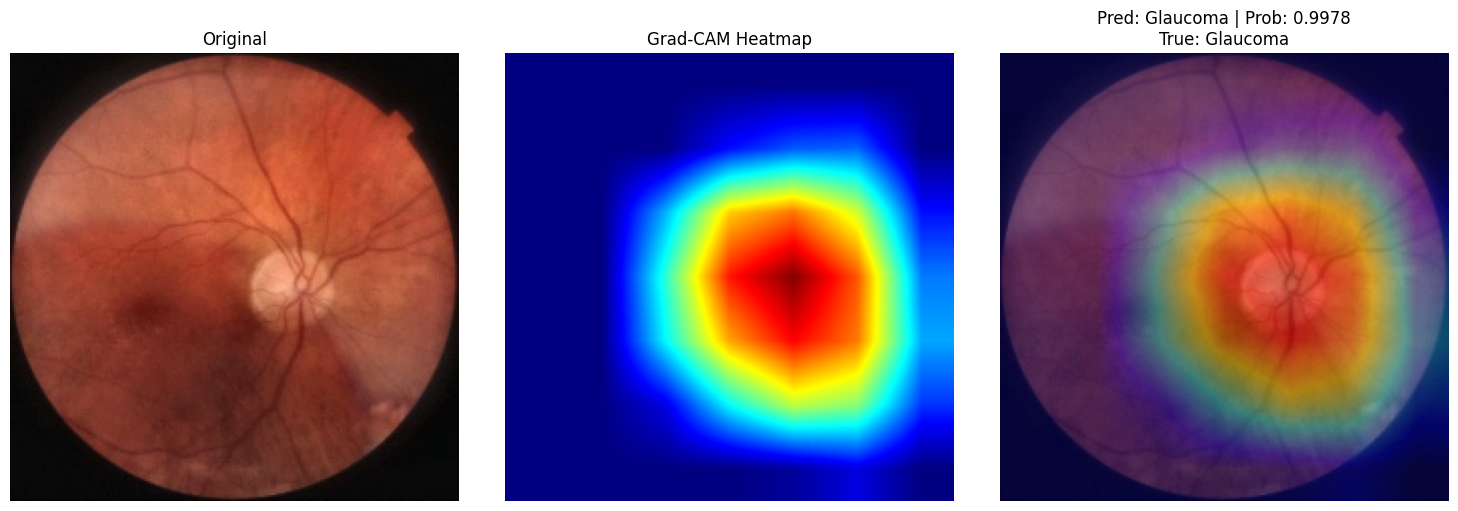

{'image_path': '..\\data\\processed\\preprocessed_glaucoma\\47_5.jpg', 'pred_prob': 0.9978173971176147, 'pred_class': 1, 'true_label': 1, 'saved_path': None}
Correctly predicted normal case


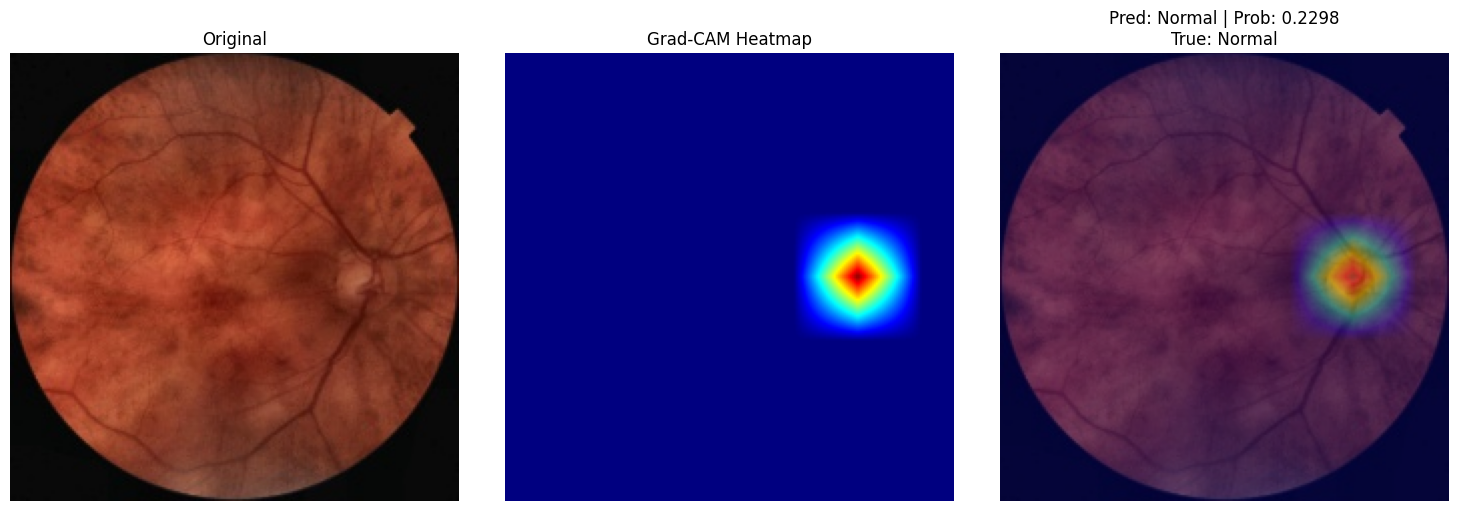

{'image_path': '..\\data\\processed\\preprocessed_glaucoma\\227_1.jpg', 'pred_prob': 0.22982089221477509, 'pred_class': 0, 'true_label': 0, 'saved_path': None}


In [ ]:
# Show Grad-CAM for:
# 1) one correctly predicted glaucoma case
# 2) one correctly predicted normal case

if test_df is None or pred_df is None:
    print("test_df or pred_df is not available.")
else:
    # Correct glaucoma
    if glaucoma_correct is not None and len(glaucoma_correct) > 0:
        print("=" * 80)
        print("Correctly predicted glaucoma case")
        row = glaucoma_correct.sample(1, random_state=44).iloc[0]
        image_path = Path(IMAGE_DIR) / row["Image Name"]
        result_glaucoma = show_gradcam(image_path, true_label=1, save=False)
        print(result_glaucoma)
    else:
        print("No correctly predicted glaucoma case found.")

    # Correct normal
    if normal_correct is not None and len(normal_correct) > 0:
        print("=" * 80)
        print("Correctly predicted normal case")
        row = glaucoma_correct.sample(1, random_state=44).iloc[0]
        image_path = Path(IMAGE_DIR) / row["Image Name"]
        result_normal = show_gradcam(image_path, true_label=0, save=False)
        print(result_normal)
    else:
        print("No correctly predicted normal case found.")
